In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load data from your CSVs

def load_yfinance_csv(path, asset_name):
    df = pd.read_csv(path)
    df = df.iloc[2:].copy()
    df.rename(columns={"Price": "Date"}, inplace=True)
    df = df[["Date", "Close"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df[asset_name] = pd.to_numeric(df["Close"], errors="coerce")
    df = df[["Date", asset_name]].dropna()
    return df


# 1. Load KO and PEP
ko = load_yfinance_csv("KO_daily.csv", "KO")
pep = load_yfinance_csv("PEP_daily.csv", "PEP")

df = pd.merge(ko, pep, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

In [4]:
# Compute returns and log prices

df["KO"] = pd.to_numeric(df["KO"], errors="coerce")
df["PEP"] = pd.to_numeric(df["PEP"], errors="coerce")

df = df.dropna(subset=["KO", "PEP"])
df = df[(df["KO"] > 0) & (df["PEP"] > 0)].copy()
df = df.sort_values("Date").reset_index(drop=True)

df["KO_ret"] = df["KO"].pct_change()
df["PEP_ret"] = df["PEP"].pct_change()

df["log_KO"] = np.log(df["KO"])
df["log_PEP"] = np.log(df["PEP"])

training_set = df[(df["Date"] >= "2000-01-01") & (df["Date"] < "2020-01-01")].copy().reset_index(drop=True)
test_set = df[df["Date"] >= "2020-01-01"].copy().reset_index(drop=True)

In [5]:
def position_size_power(
        z,
        full_size_z,
        p,
        entry_z=1.4,
        max_position_pct=100.0
):
    """
    Converts abs(z) into a smooth position size.

    p < 1  = aggressive early scaling
    p = 1  = linear scaling
    p > 1  = slower early scaling
    """

    abs_z = abs(z)

    if abs_z < entry_z:
        return 0.0

    if abs_z >= full_size_z:
        return max_position_pct

    scaled_signal = (abs_z - entry_z) / (full_size_z - entry_z)

    return max_position_pct * (scaled_signal ** p)


def target_position_power_ratchet(
        today_z,
        previous_position,
        full_size_z,
        p,
        entry_z=1.4,
        exit_z=0.9,
        e_stop=3.3,
        max_position_pct=100.0
):
    """
    Ratcheting position rule.

    Positive position = long spread = long PEP, short KO.
    Negative position = short spread = short PEP, long KO.

    Main rule:
        - enter when abs(z) >= entry_z
        - scale UP if signal strengthens
        - do NOT scale down if signal weakens
        - exit only if abs(z) <= exit_z
        - emergency exit if abs(z) >= e_stop
    """

    abs_z = abs(today_z)

    # Emergency stop
    if abs_z >= e_stop:
        return 0.0

    # Normal exit
    if previous_position != 0:
        if abs_z <= exit_z:
            return 0.0

    # If flat, only enter after entry_z
    if previous_position == 0:
        if abs_z < entry_z:
            return 0.0

        new_size = position_size_power(
            z=today_z,
            full_size_z=full_size_z,
            p=p,
            entry_z=entry_z,
            max_position_pct=max_position_pct
        )

        if today_z > 0:
            return -new_size  # short spread: short PEP, long KO

        if today_z < 0:
            return new_size  # long spread: long PEP, short KO

        return 0.0

    # Currently long spread
    if previous_position > 0:

        # If signal flips sign, exit
        if today_z > 0:
            return 0.0

        new_size = position_size_power(
            z=today_z,
            full_size_z=full_size_z,
            p=p,
            entry_z=entry_z,
            max_position_pct=max_position_pct
        )

        size = max(abs(previous_position), new_size)
        return size

    # Currently short spread
    if previous_position < 0:

        # If signal flips sign, exit
        if today_z < 0:
            return 0.0

        new_size = position_size_power(
            z=today_z,
            full_size_z=full_size_z,
            p=p,
            entry_z=entry_z,
            max_position_pct=max_position_pct
        )

        size = max(abs(previous_position), new_size)
        return -size

    return 0.0


def dollar_positions_from_percent(
        target_position_pct,
        beta,
        current_equity
):
    """
    Converts signed target spread position into PEP/KO dollar positions.

    Positive position = long PEP, short KO.
    Negative position = short PEP, long KO.
    """

    if target_position_pct == 0 or np.isnan(beta):
        return 0.0, 0.0

    gross_exposure = current_equity * abs(target_position_pct) / 100.0

    pep_weight = 1.0 / (1.0 + abs(beta))
    ko_weight = abs(beta) / (1.0 + abs(beta))

    pep_dollars = gross_exposure * pep_weight
    ko_dollars = gross_exposure * ko_weight

    if target_position_pct > 0:
        # Long spread: long PEP, short KO
        return pep_dollars, -ko_dollars

    else:
        # Short spread: short PEP, long KO
        return -pep_dollars, ko_dollars


def trade_dollars_from_targets(
        target_pep_dollars,
        target_ko_dollars,
        previous_pep_dollars,
        previous_ko_dollars
):
    """
    Calculates how much PEP and KO exposure to add/remove today.
    """

    pep_trade_dollars = target_pep_dollars - previous_pep_dollars
    ko_trade_dollars = target_ko_dollars - previous_ko_dollars

    return pep_trade_dollars, ko_trade_dollars

In [6]:
def run_validation_backtest_power_ratchet(
        original_df,
        validation_start="2020-01-01",
        full_size_z=3.0,
        p=0.3,
        lookback=78,
        entry_z=1.4,
        exit_z=0.9,
        e_stop=3.3,
        starting_equity=100000,
        max_position_pct=100.0
):
    """
    Runs validation from validation_start onward.

    Important:
        Uses data before validation_start for rolling beta/z-score warmup,
        but only trades and measures performance after validation_start.
    """

    df = original_df.copy()
    df = df.sort_values("Date").reset_index(drop=True)

    validation_start = pd.to_datetime(validation_start)

    df["beta"] = np.nan
    df["spread"] = np.nan
    df["zscore"] = np.nan

    # --------------------------------------------------
    # 1. Compute rolling beta, spread, and z-score on full data
    # --------------------------------------------------
    for i in range(lookback, len(df)):
        train = df.iloc[i - lookback:i]

        x = train["log_KO"].values
        y = train["log_PEP"].values

        beta = np.polyfit(x, y, 1)[0]
        df.loc[i, "beta"] = beta

        train_spread = train["log_PEP"] - beta * train["log_KO"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = df.loc[i, "log_PEP"] - beta * df.loc[i, "log_KO"]

        df.loc[i, "spread"] = current_spread
        df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    # --------------------------------------------------
    # 2. Backtest only from validation_start onward
    # --------------------------------------------------
    df["equity"] = np.nan
    df["daily_pnl"] = 0.0
    df["strategy_ret"] = 0.0

    df["target_position_pct"] = 0.0
    df["pep_dollars"] = 0.0
    df["ko_dollars"] = 0.0

    df["pep_trade_dollars"] = 0.0
    df["ko_trade_dollars"] = 0.0

    current_equity = starting_equity

    previous_position_pct = 0.0
    previous_pep_dollars = 0.0
    previous_ko_dollars = 0.0

    start_indices = df.index[df["Date"] >= validation_start]

    if len(start_indices) == 0:
        raise ValueError("validation_start is after the final date in df.")

    start_idx = start_indices[0]

    for i in range(start_idx, len(df)):

        # --------------------------------------------------
        # A. Realize today's PnL from yesterday's holdings
        # --------------------------------------------------
        if i > start_idx:
            pep_ret = df.loc[i, "PEP_ret"]
            ko_ret = df.loc[i, "KO_ret"]

            if pd.isna(pep_ret):
                pep_ret = 0.0
            if pd.isna(ko_ret):
                ko_ret = 0.0

            pnl = previous_pep_dollars * pep_ret + previous_ko_dollars * ko_ret

            old_equity = current_equity
            current_equity += pnl

            df.loc[i, "daily_pnl"] = pnl
            df.loc[i, "strategy_ret"] = 0.0 if old_equity == 0 else pnl / old_equity

        # --------------------------------------------------
        # B. Generate today's target percent position
        # --------------------------------------------------
        today_z = df.loc[i, "zscore"]

        if pd.isna(today_z):
            target_position_pct = 0.0
        else:
            target_position_pct = target_position_power_ratchet(
                today_z=today_z,
                previous_position=previous_position_pct,
                full_size_z=full_size_z,
                p=p,
                entry_z=entry_z,
                exit_z=exit_z,
                e_stop=e_stop,
                max_position_pct=max_position_pct
            )

        # --------------------------------------------------
        # C. Convert target percent into dollar positions
        # --------------------------------------------------
        beta = df.loc[i, "beta"]

        target_pep_dollars, target_ko_dollars = dollar_positions_from_percent(
            target_position_pct=target_position_pct,
            beta=beta,
            current_equity=current_equity
        )

        # --------------------------------------------------
        # D. Calculate trade dollars
        # --------------------------------------------------
        pep_trade_dollars, ko_trade_dollars = trade_dollars_from_targets(
            target_pep_dollars=target_pep_dollars,
            target_ko_dollars=target_ko_dollars,
            previous_pep_dollars=previous_pep_dollars,
            previous_ko_dollars=previous_ko_dollars
        )

        # --------------------------------------------------
        # E. Store values
        # --------------------------------------------------
        df.loc[i, "equity"] = current_equity
        df.loc[i, "target_position_pct"] = target_position_pct

        df.loc[i, "pep_dollars"] = target_pep_dollars
        df.loc[i, "ko_dollars"] = target_ko_dollars

        df.loc[i, "pep_trade_dollars"] = pep_trade_dollars
        df.loc[i, "ko_trade_dollars"] = ko_trade_dollars

        # --------------------------------------------------
        # F. Update previous holdings
        # --------------------------------------------------
        previous_position_pct = target_position_pct
        previous_pep_dollars = target_pep_dollars
        previous_ko_dollars = target_ko_dollars

    # --------------------------------------------------
    # 3. Validation metrics
    # --------------------------------------------------
    validation_df = df[df["Date"] >= validation_start].copy()

    validation_df["equity"] = validation_df["equity"].ffill().fillna(starting_equity)
    validation_df["equity_curve"] = validation_df["equity"] / starting_equity

    mean_ret = validation_df["strategy_ret"].mean()
    std_ret = validation_df["strategy_ret"].std()

    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
    total_return = validation_df["equity"].iloc[-1] / starting_equity - 1

    rolling_max = validation_df["equity"].cummax()
    drawdown = validation_df["equity"] / rolling_max - 1
    max_drawdown = drawdown.min()

    num_trades = (validation_df["target_position_pct"].diff().abs() > 0).sum()

    total_turnover = (
            validation_df["pep_trade_dollars"].abs() + validation_df["ko_trade_dollars"].abs()
    ).sum()

    return {
        "validation_start": validation_start,
        "full_size_z": full_size_z,
        "p": p,
        "lookback": lookback,
        "entry_z": entry_z,
        "exit_z": exit_z,
        "e_stop": e_stop,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "num_trades": num_trades,
        "final_equity": validation_df["equity"].iloc[-1],
        "total_turnover": total_turnover,
        "validation_df": validation_df,
        "full_backtest_df": df
    }

In [7]:
validation_result = run_validation_backtest_power_ratchet(
    df,
    validation_start="2020-01-01",
    full_size_z=3.0,
    p=0.3,
    lookback=78,
    entry_z=1.4,
    exit_z=0.9,
    e_stop=3.3,
    starting_equity=100_000,
    max_position_pct=100.0
)

print("Validation Sharpe:", validation_result["sharpe"])
print("Validation Total Return:", validation_result["total_return"])
print("Validation Max Drawdown:", validation_result["max_drawdown"])
print("Validation Number of Trades:", validation_result["num_trades"])
print("Validation Final Equity:", validation_result["final_equity"])
print("Validation Total Turnover:", validation_result["total_turnover"])

validation_df = validation_result["validation_df"]
validation_df

Validation Sharpe: 0.09495572404350931
Validation Total Return: 0.026078268634987856
Validation Max Drawdown: -0.1505009127782564
Validation Number of Trades: 269
Validation Final Equity: 102607.82686349878
Validation Total Turnover: 13850418.421066552


,Date,KO,PEP,KO_ret,PEP_ret,log_KO,log_PEP,beta,spread,zscore,equity,daily_pnl,strategy_ret,target_position_pct,pep_dollars,ko_dollars,pep_trade_dollars,ko_trade_dollars,equity_curve
12001,2020-01-02,54.990002,135.820007,-0.006504,-0.006219,4.007151,4.911331,0.559931,2.667602,-1.690760,100000.000000,0.000000,0.000000,59.954873,38434.307218,-21520.565313,38434.307218,-21520.565313,1.000000
12002,2020-01-03,54.689999,135.630005,-0.005456,-0.001399,4.001681,4.909931,0.550873,2.705512,-1.429675,100063.640602,63.640602,0.000636,59.954873,38683.389234,-21309.638939,249.082016,210.926374,1.000636
12003,2020-01-06,54.669998,136.149994,-0.000366,0.003834,4.001315,4.913757,0.545177,2.732330,-0.883069,100219.741093,156.100491,0.001560,0.000000,0.000000,0.000000,-38683.389234,21309.638939,1.002197
12004,2020-01-07,54.250000,134.009995,-0.007682,-0.015718,3.993603,4.897914,0.539423,2.743673,-2.319287,100219.741093,-0.000000,-0.000000,84.683619,55130.854136,-29738.849546,55130.854136,-29738.849546,1.002197
12005,2020-01-08,54.349998,134.699997,0.001843,0.005149,3.995445,4.903050,0.532702,2.774670,-1.733897,100448.786363,229.045269,0.002285,84.683619,55499.164780,-29564.502725,368.310644,174.346821,1.004488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13591,2026-05-01,78.580002,157.410004,-0.002285,-0.006814,4.364117,5.058854,1.238358,-0.345487,-1.717495,102820.020542,-180.122538,-0.001749,97.515883,44794.370955,-55471.480377,-226.027970,-50.379886,1.028200
13592,2026-05-04,78.190002,154.589996,-0.004963,-0.017915,4.359142,5.040776,1.228609,-0.314906,-2.267187,102292.837150,-527.183393,-0.005127,97.515883,44759.644276,-54992.119514,-34.726679,479.360864,1.022928
13593,2026-05-05,78.480003,155.039993,0.003709,0.002911,4.362844,5.043683,1.203340,-0.206303,-2.238367,102219.166577,-73.670572,-0.000720,97.515883,45240.366951,-54439.556329,480.722675,552.563185,1.022192
13594,2026-05-06,79.230003,155.960007,0.009557,0.005934,4.372355,5.049600,1.182964,-0.122739,-2.384716,101967.369020,-251.797557,-0.002463,97.515883,45550.168897,-53884.211771,309.801945,555.344557,1.019674


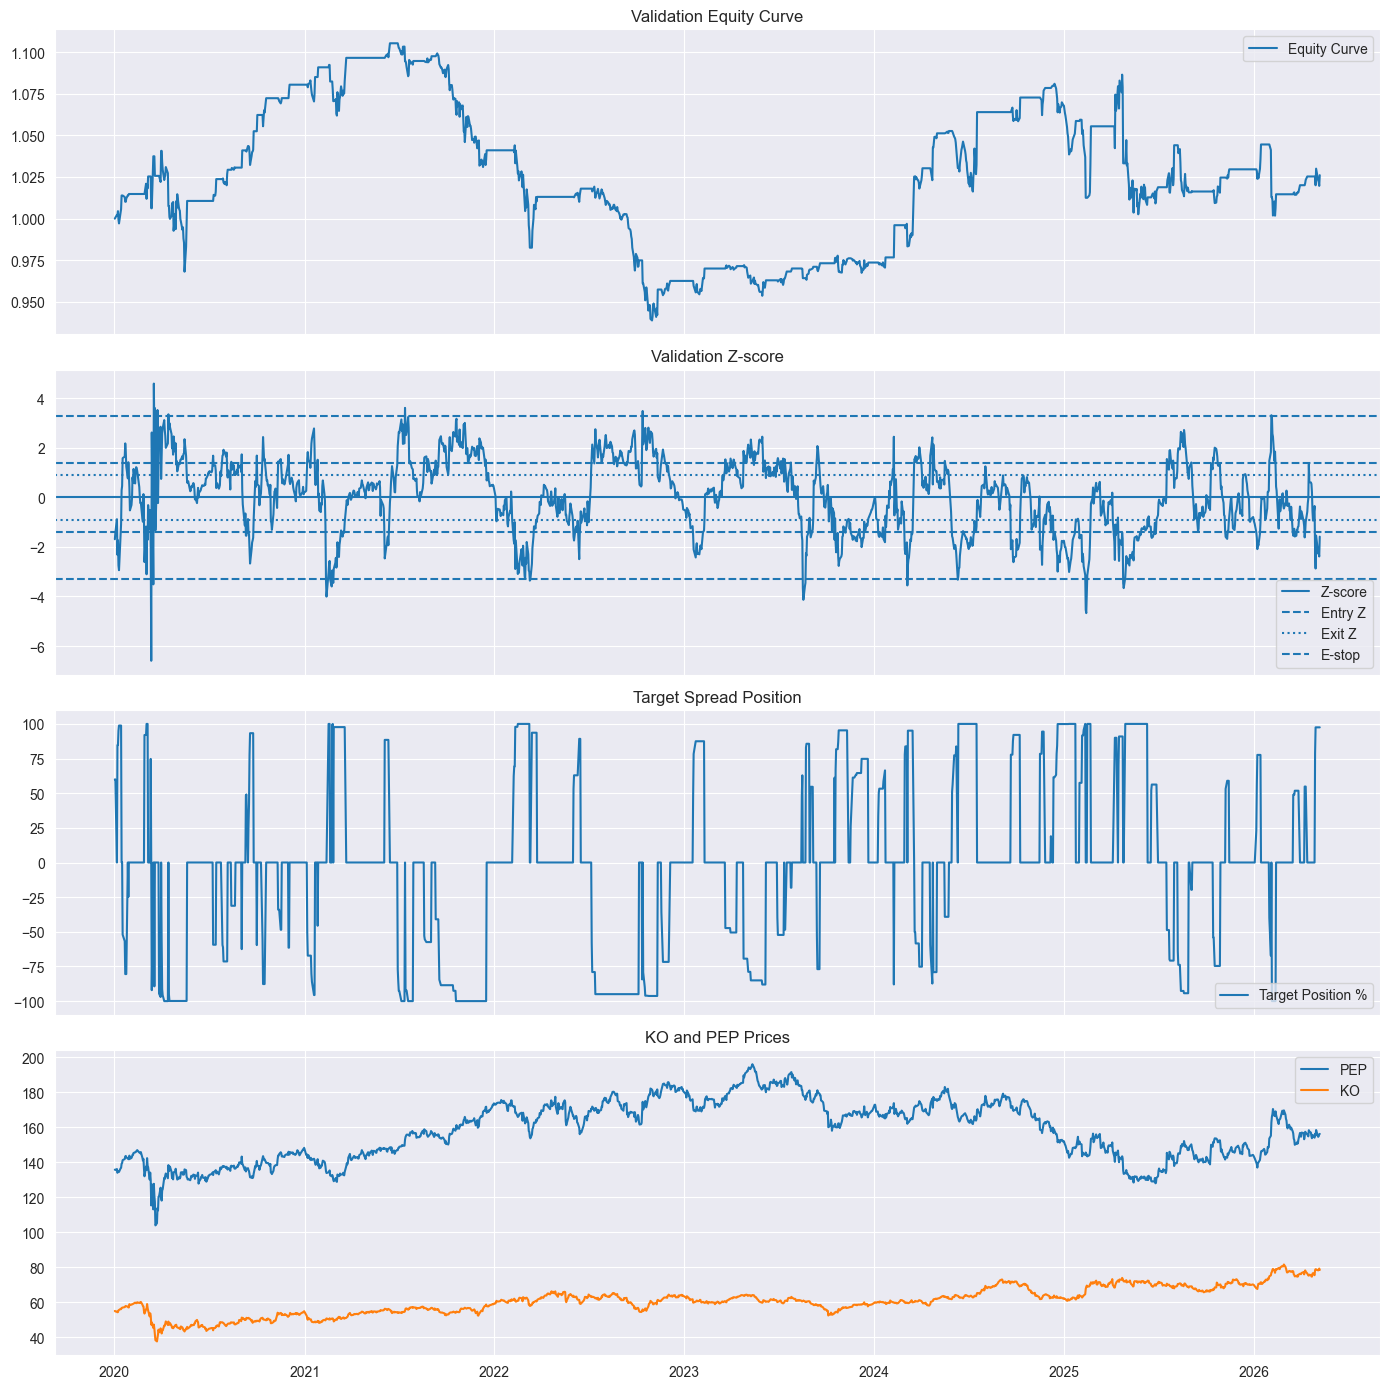

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(validation_df["Date"], validation_df["equity_curve"], label="Equity Curve")
axes[0].set_title("Validation Equity Curve")
axes[0].legend()

axes[1].plot(validation_df["Date"], validation_df["zscore"], label="Z-score")
axes[1].axhline(1.4, linestyle="--", label="Entry Z")
axes[1].axhline(-1.4, linestyle="--")
axes[1].axhline(0.9, linestyle=":", label="Exit Z")
axes[1].axhline(-0.9, linestyle=":")
axes[1].axhline(3.3, linestyle="--", label="E-stop")
axes[1].axhline(-3.3, linestyle="--")
axes[1].axhline(0, linestyle="-")
axes[1].set_title("Validation Z-score")
axes[1].legend()

axes[2].plot(validation_df["Date"], validation_df["target_position_pct"], label="Target Position %")
axes[2].set_title("Target Spread Position")
axes[2].legend()

axes[3].plot(validation_df["Date"], validation_df["PEP"], label="PEP")
axes[3].plot(validation_df["Date"], validation_df["KO"], label="KO")
axes[3].set_title("KO and PEP Prices")
axes[3].legend()

plt.tight_layout()
plt.show()